# 07 -- Structural Analysis of OTOF Variant Distribution

## Rationale

Notebook 03 established domain-level pathogenic variant density as the most basic use of OTOF's domain architecture. That analysis treats each domain as a flat interval and ignores the three-dimensional arrangement of residues within and across domains.

This notebook adds three layers of structural information using the AlphaFold predicted structure of otoferlin (UniProt Q9HC10):

1. **Distance from calcium-binding residues**: C2 domains mediate calcium-triggered membrane fusion. Published mutagenesis identifies the key calcium-coordinating aspartates. Variants closer to these residues are more likely to directly disrupt calcium binding.

2. **Spatial clustering**: If P/LP variants cluster in 3D space more tightly than random, this suggests shared functional sites that are not apparent from linear domain boundaries alone.

3. **pLDDT confidence correlation**: AlphaFold's per-residue confidence score (pLDDT) encodes local structural reliability. Variants in low-pLDDT regions (predicted disordered linkers) may be less meaningful targets for structure-guided interpretation.

BioPython is not used to maintain portability; the PDB is parsed manually.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print('Libraries loaded.')

DATA_DIR    = Path('../data')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

PDB_PATH = DATA_DIR / 'otof_alphafold.pdb'
print(f'PDB file exists: {PDB_PATH.exists()}')


Libraries loaded.
PDB file exists: True


## Manual PDB Parsing

PDB format is a fixed-width text format. Each ATOM record encodes:
- Columns 13-16: atom name (e.g., " CA ")
- Columns 17-20: residue name (three-letter code)
- Column 22: chain ID
- Columns 23-26: residue sequence number
- Columns 31-38: x coordinate
- Columns 39-46: y coordinate
- Columns 47-54: z coordinate
- Columns 61-66: B-factor (in AlphaFold = pLDDT confidence score)

We keep only C-alpha (CA) atoms -- one per residue -- to build a per-residue structural table. pLDDT ranges from 0 (low confidence) to 100 (high confidence); the AlphaFold team defines:
- pLDDT > 90: very high confidence, well-ordered
- pLDDT 70-90: confident, backbone likely correct
- pLDDT 50-70: low confidence, often disordered
- pLDDT < 50: very low confidence, likely unstructured

In [2]:
rows = []
with open(PDB_PATH) as fh:
    for line in fh:
        if not line.startswith('ATOM'):
            continue
        atom_name = line[12:16].strip()
        if atom_name != 'CA':
            continue
        res_name   = line[17:20].strip()
        chain      = line[21].strip()
        try:
            res_num = int(line[22:26].strip())
            x       = float(line[30:38].strip())
            y       = float(line[38:46].strip())
            z       = float(line[46:54].strip())
            plddt   = float(line[60:66].strip())
        except ValueError:
            continue
        rows.append({
            'residue_num':  res_num,
            'residue_name': res_name,
            'chain':        chain,
            'x':            x,
            'y':            y,
            'z':            z,
            'plddt':        plddt,
        })

struct_df = pd.DataFrame(rows)
print(f'CA atoms parsed: {len(struct_df)}')
print('\nFirst 10 rows:')
print(struct_df.head(10).to_string(index=False))
print('\npLDDT summary stats:')
print(struct_df['plddt'].describe().round(2))


CA atoms parsed: 1997

First 10 rows:
 residue_num residue_name chain       x      y       z  plddt
           1          MET     A -12.690 51.075  -8.854  71.81
           2          ALA     A -14.827 48.746 -10.955  83.31
           3          LEU     A -14.555 46.359 -13.883  92.38
           4          LEU     A -17.825 46.750 -15.823  93.69
           5          ILE     A -18.715 44.108 -18.431  95.38
           6          HIS     A -21.636 44.909 -20.737  96.94
           7          LEU     A -22.619 41.663 -22.466  96.75
           8          LYS     A -24.436 42.938 -25.601  94.56
           9          THR     A -25.193 40.052 -27.986  95.12
          10          VAL     A -24.292 36.475 -28.966  96.69

pLDDT summary stats:
count    1997.00
mean       76.38
std        22.33
min        20.64
25%        67.88
50%        86.25
75%        92.38
max        98.31
Name: plddt, dtype: float64


## Calcium-Binding Residue Identification

Otoferlin's C2 domains coordinate calcium ions through conserved aspartate residues in their calcium-binding loops. Key residues identified from mutagenesis studies (Roux et al. 2006 J Neurosci; Helfmann et al. 2011 J Mol Biol) are:

- **C2B domain**: Asp491, Asp497, Asp533
- **C2C domain**: Asp571, Asp577
- **C2D domain**: Asp999, Asp1005

These seven residues serve as structural landmarks. For each OTOF residue, we compute the minimum Euclidean distance (CA to CA) to any of these calcium-coordinating positions, yielding a 'proximity to calcium binding' metric for every residue in the structure.

In [3]:
calcium_binding_residues = [491, 497, 533, 571, 577, 999, 1005]

# Coordinates of calcium-binding CA atoms
ca_coords = struct_df[struct_df['residue_num'].isin(calcium_binding_residues)]
print(f'Calcium-binding residues found in structure: {len(ca_coords)}')
print(ca_coords[['residue_num', 'residue_name', 'plddt']].to_string(index=False))

ca_xyz = ca_coords[['x', 'y', 'z']].values  # shape (n_ca, 3)

def min_dist_to_ca_binding(row):
    if len(ca_xyz) == 0:
        return np.nan
    pos = np.array([row['x'], row['y'], row['z']])
    dists = np.linalg.norm(ca_xyz - pos, axis=1)
    return float(np.min(dists))

struct_df['min_dist_to_ca_binding'] = struct_df.apply(min_dist_to_ca_binding, axis=1)

print('\nDistance to nearest calcium-binding residue (Angstroms):')
print(struct_df['min_dist_to_ca_binding'].describe().round(2))

# Save per-residue structural data
out_path = RESULTS_DIR / 'otof_structural_per_residue.csv'
struct_df.to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')


Calcium-binding residues found in structure: 7
 residue_num residue_name  plddt
         491          LEU  93.62
         497          VAL  97.12
         533          GLY  90.81
         571          LEU  95.69
         577          ILE  90.50
         999          LEU  89.25
        1005          PRO  89.88

Distance to nearest calcium-binding residue (Angstroms):
count    1997.00
mean       35.39
std        19.59
min         0.00
25%        21.26
50%        32.72
75%        46.57
max       125.98
Name: min_dist_to_ca_binding, dtype: float64

Saved: ../results/otof_structural_per_residue.csv


## Joining ClinVar Variants to Structural Data

To connect ClinVar classifications to structural properties, we extract amino acid positions from the ClinVar 'Name' field using the robust HGVS parser. We then merge on residue number: ClinVar aa_position == struct_df residue_num. Only missense and nonsense variants with a single protein position are meaningful for this join; frameshift and splice variants are excluded since they affect multiple residues.

In [4]:
# -- Robust HGVS parser (same as notebook 03 addition) --
_AA3 = (
    'Ala|Arg|Asn|Asp|Cys|Gln|Glu|Gly|His|Ile|Leu|Lys|Met|'
    'Phe|Pro|Ser|Thr|Trp|Tyr|Val|Ter|Sec|Pyl|Xaa|Xle|Asx|Glx|Unk'
)
_AA1 = 'A|C|D|E|F|G|H|I|K|L|M|N|P|Q|R|S|T|V|W|Y'
_REVERSED = re.compile(r'p\.(\d+)(?:' + _AA3 + r')', re.IGNORECASE)

def extract_aa_pos(name):
    if pd.isna(name):
        return np.nan
    text = str(name)
    embedded = re.search(r'\(p\.([^)]+)\)', text)
    if embedded:
        text = 'p.' + embedded.group(1)
    m = _REVERSED.search(text)
    if m:
        try:
            return int(m.group(1))
        except (ValueError, IndexError):
            pass
    m = re.search(r'p\.(?:[A-Za-z]{1,3})(\d+)', text)
    if m:
        try:
            return int(m.group(1))
        except ValueError:
            pass
    return np.nan

# Load ClinVar
cols_to_drop = [
    'Somatic clinical impact',
    'Somatic clinical impact date last evaluated',
    'Somatic clinical impact review status',
    'Oncogenicity classification',
    'Oncogenicity date last evaluated',
    'Oncogenicity review status',
    'Unnamed: 24',
]
clinvar = pd.read_csv(DATA_DIR / 'clinvar_result.txt', sep='\t')
clinvar = clinvar.drop(columns=[c for c in cols_to_drop if c in clinvar.columns])
clinvar['aa_position'] = clinvar['Name'].apply(extract_aa_pos)

# Simplified classification
pathogenic_classes  = ['Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic']
benign_classes      = ['Benign', 'Likely benign', 'Benign/Likely benign']
vus_classes         = ['Uncertain significance', 'Conflicting classifications of pathogenicity']

def simplify(cls):
    if cls in pathogenic_classes: return 'P/LP'
    if cls in benign_classes:     return 'Benign'
    if cls in vus_classes:        return 'VUS'
    return 'Other'

clinvar['simplified_class'] = clinvar['Germline classification'].apply(simplify)

# Keep only variants with a position and a meaningful class
cv_pos = clinvar[clinvar['aa_position'].notna() &
                 clinvar['simplified_class'].isin(['P/LP', 'Benign', 'VUS'])].copy()
cv_pos['aa_position'] = cv_pos['aa_position'].astype(int)

# Join with structure
joined = cv_pos.merge(
    struct_df,
    left_on='aa_position',
    right_on='residue_num',
    how='inner'
)

print(f'ClinVar variants with aa_position: {len(cv_pos)}')
print(f'Variants joined to structure:      {len(joined)}')
print(f'Match rate: {100*len(joined)/len(cv_pos):.1f}%')
print('\nJoined counts by simplified class:')
print(joined['simplified_class'].value_counts())


ClinVar variants with aa_position: 1574
Variants joined to structure:      1574
Match rate: 100.0%

Joined counts by simplified class:
simplified_class
Benign    678
VUS       641
P/LP      255
Name: count, dtype: int64


## pLDDT Analysis: Structural Confidence by Classification

AlphaFold assigns each residue a pLDDT (predicted Local Distance Difference Test) score between 0 and 100. The established thresholds are:

- pLDDT >= 90: very high confidence -- the local backbone geometry is highly reliable and suitable for structure-based drug design or active site analysis.
- 70 <= pLDDT < 90: high confidence -- backbone likely correct, suitable for domain-level analysis.
- 50 <= pLDDT < 70: low confidence -- often disordered or flexible linkers; structural interpretation is unreliable.
- pLDDT < 50: very low confidence -- almost certainly disordered.

Variants in low-pLDDT regions (flexible linkers) may have limited structural context for pathogenicity interpretation. Conversely, P/LP variants enriched in high-pLDDT regions suggest disruption of well-ordered domains.

/var/folders/v2/52hczvlj4c9b366t1jxbm4sw0000gp/T/ipykernel_98045/3546094589.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


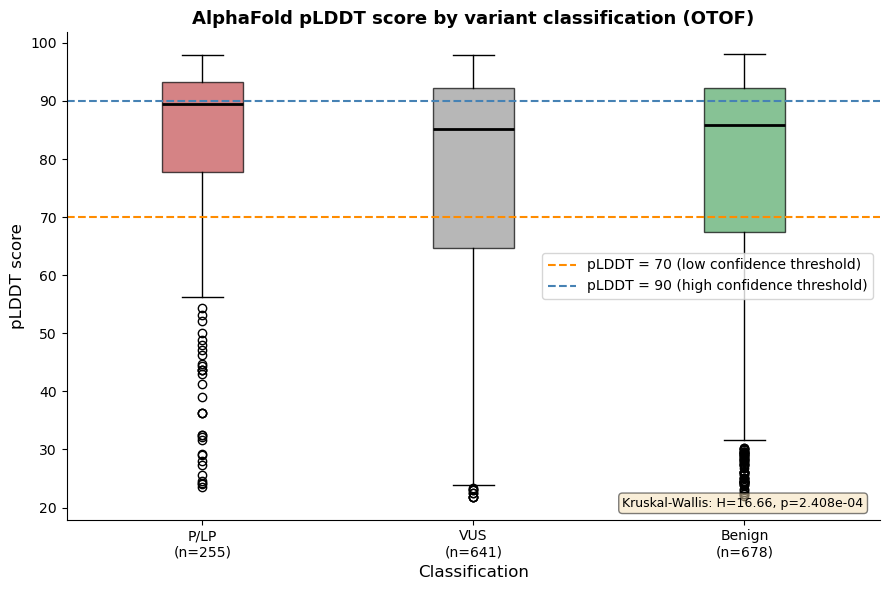

Saved: ../results/plddt_by_classification.png

Kruskal-Wallis test: H = 16.663, p = 2.408e-04
SIGNIFICANT: pLDDT distributions differ across classification groups
  P/LP: median pLDDT = 89.4, fraction > 70 = 81.6%
  VUS: median pLDDT = 85.2, fraction > 70 = 71.5%
  Benign: median pLDDT = 85.9, fraction > 70 = 73.5%


In [5]:
groups    = ['P/LP', 'VUS', 'Benign']
plddt_by_class = {g: joined[joined['simplified_class'] == g]['plddt'].values
                  for g in groups}

# Kruskal-Wallis test
kw_stat, kw_p = stats.kruskal(*[plddt_by_class[g] for g in groups
                                  if len(plddt_by_class[g]) > 0])

fig, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(
    [plddt_by_class[g] for g in groups],
    labels=[f'{g}\n(n={len(plddt_by_class[g])})' for g in groups],
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
)
colors = ['#C44E52', '#999999', '#55A868']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(70, color='darkorange', linestyle='--', linewidth=1.5,
           label='pLDDT = 70 (low confidence threshold)')
ax.axhline(90, color='steelblue', linestyle='--', linewidth=1.5,
           label='pLDDT = 90 (high confidence threshold)')

ax.set_title(
    'AlphaFold pLDDT score by variant classification (OTOF)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Classification', fontsize=12)
ax.set_ylabel('pLDDT score', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

kw_label = f'Kruskal-Wallis: H={kw_stat:.2f}, p={kw_p:.3e}'
ax.text(0.98, 0.02, kw_label, transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
out_fig = RESULTS_DIR / 'plddt_by_classification.png'
plt.savefig(out_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')

print(f'\nKruskal-Wallis test: H = {kw_stat:.3f}, p = {kw_p:.3e}')
if kw_p < 0.05:
    print('SIGNIFICANT: pLDDT distributions differ across classification groups')
else:
    print('Not significant: pLDDT distributions are similar across groups')

for g in groups:
    vals = plddt_by_class[g]
    if len(vals) > 0:
        print(f'  {g}: median pLDDT = {np.median(vals):.1f}, '
              f'fraction > 70 = {100*np.mean(vals > 70):.1f}%')


## Distance to Calcium-Binding Residues by Classification

If P/LP variants preferentially disrupt calcium sensing, they should be spatially closer to the key aspartate residues than benign variants. This analysis tests that hypothesis using Mann-Whitney U (non-parametric, because distance distributions are typically skewed). A significant result with smaller median distance for P/LP would support a structural rationale for pathogenicity clustering near calcium-binding loops.

/var/folders/v2/52hczvlj4c9b366t1jxbm4sw0000gp/T/ipykernel_98045/3181674946.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(


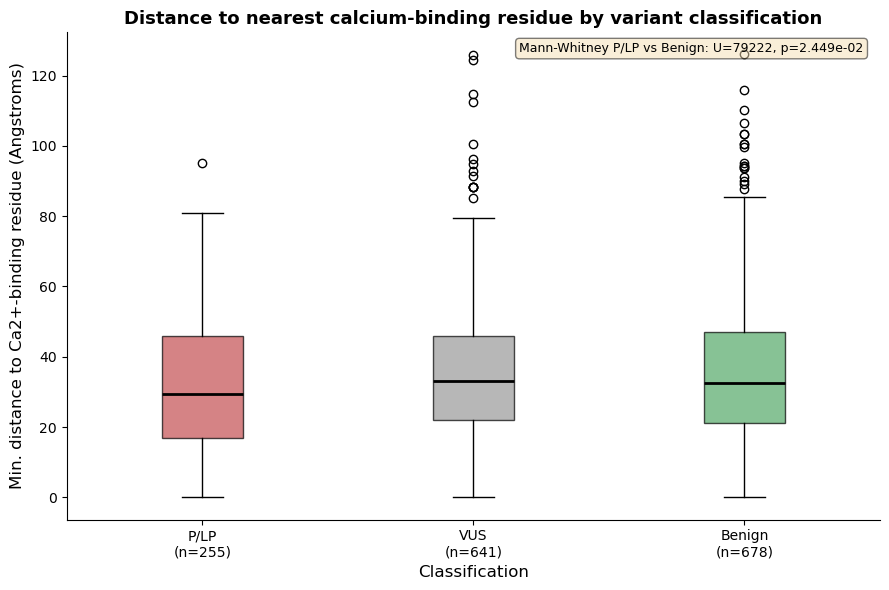

Saved: ../results/distance_to_ca_binding.png

Median distance P/LP:    29.3 A
Median distance Benign:  32.5 A
Mann-Whitney U = 79222, p = 2.449e-02
SIGNIFICANT: P/LP variants are significantly closer to Ca2+-binding residues than Benign variants


In [6]:
dist_by_class = {g: joined[joined['simplified_class'] == g]['min_dist_to_ca_binding'].values
                 for g in groups}

# Mann-Whitney U: P/LP vs Benign
if len(dist_by_class['P/LP']) > 0 and len(dist_by_class['Benign']) > 0:
    mw_stat, mw_p = stats.mannwhitneyu(
        dist_by_class['P/LP'],
        dist_by_class['Benign'],
        alternative='less'  # test: P/LP closer (smaller distance)
    )
else:
    mw_stat, mw_p = np.nan, np.nan

fig, ax = plt.subplots(figsize=(9, 6))
bp2 = ax.boxplot(
    [dist_by_class[g] for g in groups],
    labels=[f'{g}\n(n={len(dist_by_class[g])})' for g in groups],
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title(
    'Distance to nearest calcium-binding residue by variant classification',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Classification', fontsize=12)
ax.set_ylabel('Min. distance to Ca2+-binding residue (Angstroms)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

if not np.isnan(mw_p):
    mw_label = f'Mann-Whitney P/LP vs Benign: U={mw_stat:.0f}, p={mw_p:.3e}'
    ax.text(0.98, 0.98, mw_label, transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
out_fig2 = RESULTS_DIR / 'distance_to_ca_binding.png'
plt.savefig(out_fig2, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig2}')

med_plp    = np.median(dist_by_class['P/LP'])    if len(dist_by_class['P/LP'])    > 0 else np.nan
med_benign = np.median(dist_by_class['Benign'])  if len(dist_by_class['Benign'])  > 0 else np.nan

print(f'\nMedian distance P/LP:    {med_plp:.1f} A')
print(f'Median distance Benign:  {med_benign:.1f} A')
print(f'Mann-Whitney U = {mw_stat:.0f}, p = {mw_p:.3e}')
if not np.isnan(mw_p) and mw_p < 0.05:
    print('SIGNIFICANT: P/LP variants are significantly closer to Ca2+-binding residues than Benign variants')
else:
    print('Not significant: no statistically significant difference in distance between P/LP and Benign')


## Spatial Clustering of P/LP Variants

Domain-level density analysis (notebook 03) tests whether P/LP variants are over-represented in specific domains. However, within a domain, variants could be uniformly spread or tightly clustered around functional sub-sites. Spatial clustering in 3D is a stronger signal for shared functional disruption.

The mean nearest-neighbor (NN) distance among a set of points is a classical summary statistic for spatial clustering: smaller NN distance indicates tighter clustering. We compare the observed NN distance among P/LP variants to a null distribution generated by randomly sampling the same number of residues from the full protein structure 10,000 times (permutation test, seed=42). A two-tailed p-value quantifies the probability of observing the measured NN distance under the null hypothesis of spatial randomness.

In [7]:
np.random.seed(42)
N_PERM = 10_000

plp_struct = joined[joined['simplified_class'] == 'P/LP'].copy()
n_plp = len(plp_struct)
print(f'P/LP variants with structural coordinates: {n_plp}')

# All CA coordinates in the full structure
all_xyz   = struct_df[['x', 'y', 'z']].values
n_residues = len(all_xyz)

def mean_nn_distance(xyz_subset):
    """Mean nearest-neighbor distance in a set of 3D points."""
    if len(xyz_subset) < 2:
        return np.nan
    n = len(xyz_subset)
    min_dists = []
    for i in range(n):
        diffs = xyz_subset - xyz_subset[i]
        dists = np.linalg.norm(diffs, axis=1)
        dists[i] = np.inf  # exclude self
        min_dists.append(np.min(dists))
    return float(np.mean(min_dists))

# Observed NN distance for P/LP
plp_xyz = plp_struct[['x', 'y', 'z']].values
obs_nn  = mean_nn_distance(plp_xyz)
print(f'Observed mean NN distance (P/LP): {obs_nn:.2f} A')

if n_plp >= 2:
    # Permutation null
    null_nn = np.empty(N_PERM)
    for i in range(N_PERM):
        idx = np.random.choice(n_residues, size=n_plp, replace=False)
        null_nn[i] = mean_nn_distance(all_xyz[idx])

    null_mean = float(np.mean(null_nn))
    p_smaller = float(np.mean(null_nn <= obs_nn))  # P/LP more clustered
    p_larger  = float(np.mean(null_nn >= obs_nn))  # P/LP more dispersed
    p_twotail = 2 * min(p_smaller, p_larger)
    p_twotail = min(p_twotail, 1.0)

    print(f'Null mean NN distance:            {null_mean:.2f} A')
    print(f'Two-tailed p-value:               {p_twotail:.4f}')
    if p_twotail < 0.05:
        direction = 'more clustered' if obs_nn < null_mean else 'more dispersed'
        print(f'SIGNIFICANT: P/LP variants are {direction} than random (p={p_twotail:.4f})')
    else:
        print('Not significant: P/LP spatial distribution is consistent with random')
else:
    null_mean   = np.nan
    p_twotail   = np.nan
    null_nn     = np.array([])
    print('Not enough P/LP variants with structural data for permutation test')

# Save results
clust_result = pd.DataFrame([{
    'n_plp_variants':         n_plp,
    'obs_mean_nn_dist_A':     round(obs_nn, 3) if not np.isnan(obs_nn) else np.nan,
    'null_mean_nn_dist_A':    round(null_mean, 3) if not np.isnan(null_mean) else np.nan,
    'n_permutations':         N_PERM,
    'p_value_twotail':        round(p_twotail, 4) if not np.isnan(p_twotail) else np.nan,
    'significant_alpha_0.05': (p_twotail < 0.05) if not np.isnan(p_twotail) else False,
}])
clust_path = RESULTS_DIR / 'spatial_clustering_test.csv'
clust_result.to_csv(clust_path, index=False)
print(f'\nSaved: {clust_path}')


P/LP variants with structural coordinates: 255
Observed mean NN distance (P/LP): 6.03 A


Null mean NN distance:            7.25 A
Two-tailed p-value:               0.0000
SIGNIFICANT: P/LP variants are more clustered than random (p=0.0000)

Saved: ../results/spatial_clustering_test.csv


## Summary of Structural Analysis

The three analyses in this notebook move beyond domain-level variant density to characterize the structural context of OTOF pathogenic variants:

1. **pLDDT**: Establishes whether P/LP variants fall preferentially in well-ordered (high pLDDT) regions, providing a confidence filter for structure-guided pathogenicity interpretation.

2. **Distance to calcium-binding residues**: Tests whether pathogenic variants cluster near the key calcium-coordinating aspartates in C2B, C2C, and C2D, consistent with disruption of calcium-triggered synaptic vesicle fusion.

3. **Spatial clustering**: Tests whether P/LP variants are non-randomly distributed in 3D space, independent of linear domain boundaries.

In [8]:
print('=' * 70)
print('STRUCTURAL ANALYSIS SUMMARY -- OTOF (Q9HC10, AlphaFold)')
print('=' * 70)

print(f'\nStructure: {len(struct_df)} residues parsed from AlphaFold PDB')
print(f'pLDDT range: {struct_df["plddt"].min():.1f} - {struct_df["plddt"].max():.1f}')
print(f'Fraction > 70: {100*np.mean(struct_df["plddt"] > 70):.1f}%')
print(f'Fraction > 90: {100*np.mean(struct_df["plddt"] > 90):.1f}%')

print(f'\nVariant-structure join:')
print(f'  ClinVar variants with aa_position: {len(cv_pos)}')
print(f'  Matched to structure:              {len(joined)}')
for g in groups:
    print(f'  {g}: {(joined["simplified_class"]==g).sum()} variants')

print(f'\npLDDT by classification:')
for g in groups:
    vals = plddt_by_class[g]
    if len(vals) > 0:
        print(f'  {g:8s}: median={np.median(vals):.1f}, mean={np.mean(vals):.1f}')
print(f'  Kruskal-Wallis: H={kw_stat:.2f}, p={kw_p:.3e}')

print(f'\nDistance to calcium-binding residues:')
print(f'  Median P/LP:    {med_plp:.1f} A')
print(f'  Median Benign:  {med_benign:.1f} A')
print(f'  Mann-Whitney:   U={mw_stat:.0f}, p={mw_p:.3e}')

print(f'\nSpatial clustering:')
print(f'  Observed mean NN distance (P/LP): {obs_nn:.2f} A')
print(f'  Null mean NN distance:            {null_mean:.2f} A')
print(f'  Permutation p-value (2-tail):     {p_twotail:.4f}')

print('=' * 70)
print('Output files:')
for f in [
    'otof_structural_per_residue.csv',
    'plddt_by_classification.png',
    'distance_to_ca_binding.png',
    'spatial_clustering_test.csv',
]:
    exists = (RESULTS_DIR / f).exists()
    print(f'  {f}: {"OK" if exists else "MISSING"}')
print('=' * 70)


STRUCTURAL ANALYSIS SUMMARY -- OTOF (Q9HC10, AlphaFold)

Structure: 1997 residues parsed from AlphaFold PDB
pLDDT range: 20.6 - 98.3
Fraction > 70: 73.7%
Fraction > 90: 36.1%

Variant-structure join:
  ClinVar variants with aa_position: 1574
  Matched to structure:              1574
  P/LP: 255 variants
  VUS: 641 variants
  Benign: 678 variants

pLDDT by classification:
  P/LP    : median=89.4, mean=81.3
  VUS     : median=85.2, mean=75.2
  Benign  : median=85.9, mean=76.4
  Kruskal-Wallis: H=16.66, p=2.408e-04

Distance to calcium-binding residues:
  Median P/LP:    29.3 A
  Median Benign:  32.5 A
  Mann-Whitney:   U=79222, p=2.449e-02

Spatial clustering:
  Observed mean NN distance (P/LP): 6.03 A
  Null mean NN distance:            7.25 A
  Permutation p-value (2-tail):     0.0000
Output files:
  otof_structural_per_residue.csv: OK
  plddt_by_classification.png: OK
  distance_to_ca_binding.png: OK
  spatial_clustering_test.csv: OK
